In [16]:
import requests
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
from geopy.geocoders import Nominatim
import datetime
import json
import random
import time
import folium as fm
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
def sample_gaussian_in_polygon(polygon, n, sigma):
    centroid = polygon.centroid
    samples = []
    while len(samples) < n:
        x, y = np.random.normal(loc=[centroid.x, centroid.y], scale=sigma)
        pt = Point(x, y)
        if polygon.contains(pt):
            samples.append((x, y))
    return samples

In [5]:
def generate_users(n, filename='users.json'):
    # Cargar el shapefile de alcaldías
    alcaldias = gpd.read_file("./alcaldias/poligonos_alcaldias_cdmx.shp")
    
    # Datos de población por alcaldía
    poblacion = {
        "Álvaro Obregón": 759137,
        "Azcapotzalco": 432205,
        "Benito Juárez": 434153,
        "Coyoacán": 614447,
        "Cuajimalpa de Morelos": 217686,
        "Cuauhtémoc": 545884,
        "Gustavo A. Madero": 1173351,
        "Iztacalco": 404695,
        "Iztapalapa": 1835486,
        "La Magdalena Contreras": 247622,
        "Miguel Hidalgo": 414470,
        "Milpa Alta": 152685,
        "Tláhuac": 392313,
        "Tlalpan": 699928,
        "Venustiano Carranza": 443704,
        "Xochimilco": 442178
    }
    
    # Verificar coincidencia de nombres en el shapefile
    nombres_shapefile = alcaldias['NOMGEO'].tolist()
    for nombre in poblacion:
        if nombre not in nombres_shapefile:
            raise ValueError(f"Alcaldía '{nombre}' no encontrada en el shapefile.")
    
    # Preparar pesos y lista de alcaldías
    alcaldias_list = list(poblacion.keys())
    pesos = [poblacion[nombre] for nombre in alcaldias_list]
    total = sum(pesos)
    probabilidades = [p / total for p in pesos]
    
    # Mapeo de geometrías
    geometrias = {row['NOMGEO']: row['geometry'] for _, row in alcaldias.iterrows()}
    
    # Obtener datos de Mockaroo
    response = requests.get(
        "https://my.api.mockaroo.com/user_data_random",
        params={'key': 'a24c2ee0', 'count': n}
    )
    if response.status_code != 200:
        raise Exception(f"Error en Mockaroo: {response.status_code} - {response.text}")
    datos_mockaroo = response.json()
    
    # Inicializar geocodificador
    geolocator = Nominatim(user_agent="generador_usuarios")
    
    usuarios = []
    for dato in datos_mockaroo:
        # Procesar datos de Mockaroo
        nombre = dato['fullName']
        email = dato['email']
        fecha = dato['createdAtDate']
        hora = dato['createdAtTime']
        creado_en = datetime.datetime.strptime(f"{fecha} {hora}", "%Y-%m-%d %H:%M:%S")
        actualizado_en = creado_en
        
        # Asignar rol
        rol = 'user' if random.random() < 0.9 else 'owner'
        
        # Seleccionar alcaldía basada en población
        alcaldia = np.random.choice(alcaldias_list, p=probabilidades)
        poligono = geometrias[alcaldia]
        
        # Generar coordenadas
        sigma = 0.01
        coordenadas = sample_gaussian_in_polygon(poligono, 1, sigma)
        if not coordenadas:
            continue  # Omitir si no se generan coordenadas
        lon, lat = coordenadas[0]
        
        # Obtener calle mediante geocodificación inversa
        calle = None
        try:
            ubicacion = geolocator.reverse((lat, lon), exactly_one=True)
            time.sleep(1)  # Respetar límite de solicitudes
            if ubicacion:
                direccion = ubicacion.raw.get('address', {})
                calle = direccion.get('road', None)
        except Exception as e:
            print(f"Error geocodificación: {e}")
        
        # Construir objeto dirección
        direccion = {
            "estado": "Ciudad de México",
            "municipio": alcaldia,
            "ubicacion": {
                "type": "Point",
                "coordinates": [lon, lat]
            }
        }
        if calle:
            direccion["calle"] = calle
        
        # Crear usuario
        usuario = {
            "nombre": nombre,
            "email": email,
            "role": rol,
            "direccion": direccion,
            "createdAt": creado_en.isoformat(),
            "updatedAt": actualizado_en.isoformat()
        }
        usuarios.append(usuario)
    
    # Exportar a JSON
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(usuarios, f, ensure_ascii=False, indent=2)
    
    print(f"Se generaron {len(usuarios)} usuarios en '{filename}'")

In [7]:
# Ejemplo de uso
generate_users(100, "usuarios.json")

Se generaron 100 usuarios en 'usuarios.json'


In [19]:
def visualizar_datos(json_file):
    # Cargar datos generados
    with open(json_file, 'r', encoding='utf-8') as f:
        usuarios = json.load(f)
    
    # Cargar shapefile de alcaldías
    alcaldias = gpd.read_file("./alcaldias/poligonos_alcaldias_cdmx.shp")
    
    # Crear mapa base
    m = fm.Map(location=[19.4326, -99.1332], zoom_start=11, control_scale=True)
    
    # Añadir polígonos de todas las alcaldías
    for _, alcaldia in alcaldias.iterrows():
        fm.GeoJson(
            alcaldia.geometry.__geo_interface__,
            name=alcaldia['NOMGEO'],
            style_function=lambda feat: {
                "color": "#444444",
                "weight": 1,
                "fillOpacity": 0
            }
        ).add_to(m)
    
    # Añadir marcadores para cada usuario
    for usuario in usuarios:
        coords = usuario['direccion']['ubicacion']['coordinates']
        rol = usuario['role']
        
        color = 'red' if rol == 'owner' else 'blue'
        popup = f"Nombre: {usuario['nombre']}<br>Alcaldía: {usuario['direccion']['municipio']}<br>Rol: {rol}"
        
        fm.CircleMarker(
            location=[coords[1], coords[0]],  # Folium usa [lat, lon]
            radius=4,
            color=color,
            fill=True,
            fill_color=color,
            popup=popup
        ).add_to(m)
    
    # Añadir control de capas
    fm.LayerControl().add_to(m)
    
    # Mostrar mapa
    display(m)
    
    # Generar gráficas
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    
    # Gráfica de alcaldías CON BARRAS Y VALORES
    alcaldias_counts = Counter([u['direccion']['municipio'] for u in usuarios])
    alcaldias_sorted = sorted(alcaldias_counts.items(), key=lambda x: x[1], reverse=True)
    
    # Crear barras
    bars_alcaldias = ax1.bar(
        [x[0] for x in alcaldias_sorted],
        [x[1] for x in alcaldias_sorted],
        edgecolor='black',
        alpha=0.7
    )
    
    # Añadir valores
    for bar in bars_alcaldias:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.5,
            f'{height}',
            ha='center',
            va='bottom',
            rotation=90
        )

    ax1.set_title('Distribución por Alcaldía')
    ax1.set_xlabel('Alcaldía')
    ax1.set_ylabel('Número de Usuarios')
    ax1.tick_params(axis='x', rotation=90)
    ax1.set_ylim(0, max(alcaldias_counts.values()) * 1.15)
    
    # Gráfica de roles CON BARRAS Y VALORES
    roles_counts = Counter([u['role'] for u in usuarios])
    
    bars_roles = ax2.bar(
        roles_counts.keys(),
        roles_counts.values(),
        color=['blue', 'red'],
        edgecolor='black',
        alpha=0.7
    )
    
    # Añadir valores
    for bar in bars_roles:
        height = bar.get_height()
        ax2.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.5,
            f'{height}',
            ha='center',
            va='bottom'
        )
    ax2.set_title('Distribución de Roles')
    ax2.set_xlabel('Rol')
    ax2.set_ylabel('Cantidad')
    ax2.set_ylim(0, max(roles_counts.values()) * 1.15)
    
    plt.tight_layout()
    plt.show()

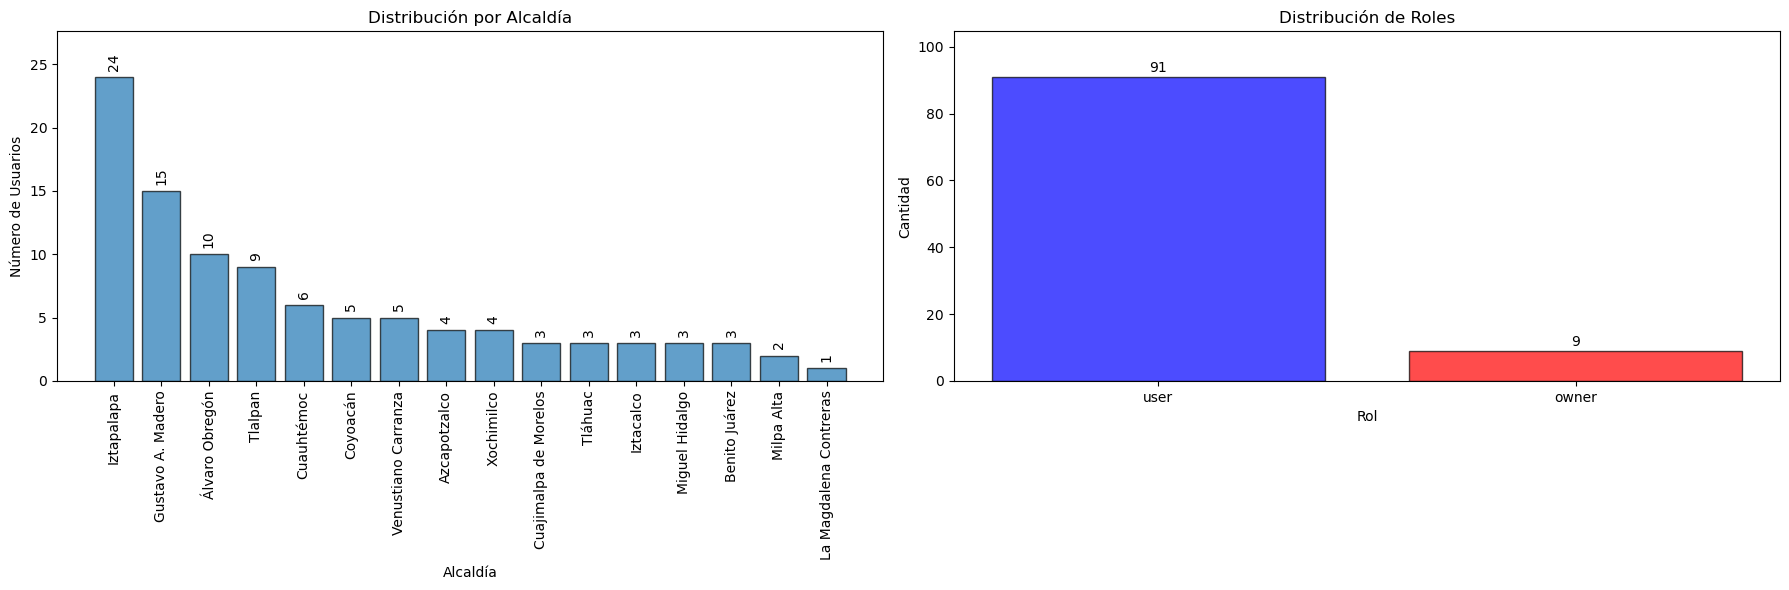

In [20]:
# Ejecutar visualización
visualizar_datos('usuarios.json')